# **Tổng quan đồ án**

Trong phạm vi đồ án này, nhóm chúng em tiến hành cài đặt lại kiến trúc mạng ANN với 1 input layer, 2 hidden layers và 1 output layer bằng CUDA

Trong đó, hàm kích hoạt của 2 hidden layers là hàm ReLU, hàm kích hoạt của output layer là softmax.

Kiến trúc ANN được cài đặt sẽ ứng dụng cho bài toán Phân loại quần áo và phụ kiện thời trang, dựa trên bộ dữ liệu [Fashion-MNIST](https://github.com/zalandoresearch/fashion-mnist) của Zalando.

### **Kiến trúc mô hình cụ thể**
| Layer (type)          |  Output Shape         |   Param # |
| :-----------          |     :---------------:          |     :----:|
| flatten (Flatten) | (None, 784) | 0   |
|dense (Dense) | (None, 128) | 100480 |
|dense_1 (Dense) | (None, 128) | 16512 |
|dense_2 (Dense) | (None, 10) | 1290 |

### **Data-set**
Bộ dữ liệu [Fashion-MNIST](https://github.com/zalandoresearch/fashion-mnist) của Zalando bao gồm:
- Tập train chứa 60000 mẫu
- Tập test chứa 10000 mẫu

với mỗi mẫu là một ảnh xám, kích thước 28x28. Dữ liệu bao gồm 10 lớp như sau

| Nhãn | Giải thích |
| --- | --- |
| 0 | T-shirt/top |
| 1 | Trouser |
| 2 | Pullover |
| 3 | Dress |
| 4 | Coat |
| 5 | Sandal |
| 6 | Shirt |
| 7 | Sneaker |
| 8 | Bag |
| 9 | Ankle boot |

### **Nội dung đã hoàn thành**
1. **HOST**  
    Thiết kế và cài đặt lại từ đầu cho kiến trúc ANN đã trình bày ở trên có thể chạy được trên CPU - HOST

1. **Kernel 1 - Basic Kernel**  
  Cài đặt các hàm kernel cơ bản để có thể chạy chương trình trên GPU - tận dụng khả năng tính toán song song của GPU để tối ưu thời gian thực thi

1. **Kernel 2 - SMEM Optimization**  
  Cải tiến hàm kernel cơ bản (tập trung vào hàm nhân ma trận) bằng cách sử dụng bộ nhớ chia sẻ - Shared memory

1. **Kernel 3 - atomicAdd Optimization**  
  Cải tiến hiệu suất của code bằng cách sử dụng Input Channel Reduction với atomic operations.

1. **Kernel 4 - Fusion Optimization**   
  Cải tiến hàm nhân ma trận bằng cách kết hợp nhiều kernel lại thành 1 kernel duy nhất để hạn chế chi phí không cần thiết.

1. **Kernel 5 - Combine atomicAdd and fusion**   
  Kết hợp ý tưởng dùng atomicAdd cho phép tính tổng các dòng và dùng fusion cho phép nhân ma trận

1. **So sánh và đánh giá (với biểu đồ)**
  Trực quan các số liệu thu được sau quá trình huấn luyện mô hình thông qua các phiên bản.

1. **Kết luận**  
  Rút ra kết luận, tự đánh giá bài làm, hướng phát triển tiếp theo.

# **0. Ghi chú**

Trong quá trình làm bài, để thuận tiện cho việc so sánh hiệu xuất cũng như độ chính xác của các phiên bản với nhau thì nhóm chúng em cài đặt thêm các hàm để ghi kết quả thực thi ra file csv. File này sẽ đóng vai trò ghi nhận lại kết quả và phục vụ việc trực quan và so sánh sau khi đã thực thi toàn bộ các phiên bản.

## Các thành phần của chương trình
1. Tạo các thông số của kiến trúc mô hình ANN, in kiến trúc ra màn hình
1. Đọc dữ liệu Huấn luyện và tạo one-hot encoding cho nhãn
1. Đọc dữ liệu Kiểm tra và tạo one-hot encoding cho nhãn
1. Khởi tạo trọng số mô hình
1. Huấn luyện mô hình với một vài số lượng epoch
1. Kiểm tra mô hình trên tập kiểm tra
1. (Tùy thuộc vào số epoch) Nếu huấn luyện $\geq$ 100 epochs, chương trình sẽ khởi tạo và kiểm tra ngẫu nhiên với 20 mẫu trong tập kiểm tra - Mục đích để xem xét chương trình thật sự hoạt động.

# 1. Cài đặt host

## 1.1 Ý tưởng

* Dữ liệu được tổ chức theo ma trận trong đó mỗi hàng là 1 mẫu dữ liệu (ảnh) và mỗi cột là giá trị của 1 pixel của ảnh đó.
* Huấn luyện:
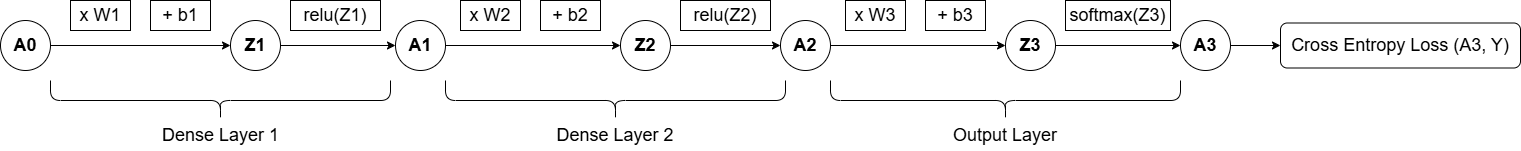
  * Lan truyền xuôi:
    * Ở layer $l$: $Z[l] = A[l-1] \cdot W[l] + b[l]$

    * Nếu không phải lớp output: $A[l] = relu(Z[l])$

    * Nếu là lớp output: $A[l] = softmax(Z[l])$
    
  * Lan nguyền ngược: Dựa vào đồ thị tính toán trên tính đạo hàm tại mỗi nút
  * Cập nhật trọng số:   
  $W[l] = W[l] - lr \cdot dW[l]$    và   $b[l] = b[l] - lr \cdot db[l]$

## 1.2 Thực nghiệm

Biên dịch chương trình host đã cài đặt trong file `host-final.cu`

In [3]:
!nvcc host-final.cu -o host

Mặc định nếu không truyền thêm gì khác, chương trình sẽ bắt đầu huấn luyện với 1 epoch.

Nhóm bắt đầu huấn luyện chương trình với 1 epoch để kiểm tra thời gian thực thi của các phần trong chương trình

### Huấn luyện trên 1 epoch

In [ ]:
!./host 1

============================ Neural Network  Structure ============================
Layer 			Number of Nodes		Output Shape		Parameter
Input Layer    		    784 		(60000, 784) 		 0
Hidden Layer 1 		    128 		(60000, 128) 		 100480
Hidden Layer 2 		    128 		(60000, 128) 		 16512
Output Layer   		    10  		(60000, 10)		 1290

Train Data Processing (Read and Change label to onehot) time: 5.76888s
Test Data Processing (Read and Change label to onehot) time: 0.94843s
Initialize Weight time: 0.00304s

STARTING TRAIN ...

Epoch 1/1 [====================] - 2.68ms/step - loss: 2.303148 - accuracy: 0.087117
		Epoch Time: 161.00000s - Forward Time: 45.00000s - Backward Time: 116.00000s - Update Time: 0.00000s

Epoch 2/1 [====================] - 0.77ms/step - loss: 2.253743 - accuracy: 0.281633
		Epoch Time: 46.00000s - Forward Time: 46.00000s - Backward Time: 0.00000s - Update Time: 0.00000s

Times of each computation:
	Matmul Time: 160.79556 seconds
	Add Bias Time: 0.07346 seconds
	ReLU Time: 0.

##### Nhận xét:
- Tổng thời gian huấn luyện (với 1 epoch) vào khoảng 161s, trong đó:
  * Thời gian thực hiện lan truyền xuôi vào khoảng 45s
  * Thời gian thực hiện lan truyện ngược vào khoảng 116s
  * Thời gian thực hiện cập nhật lại trọng số cho ma trận không đáng kể
  * Tổng thời gian thực hiện 1 epoch vào khoảng 160s
  * Thời gian lan truyền xuôi lần cuối để kiểm tra loss sau khi cập nhật trọng số rơi vào khoảng 46s


| Task                  | Time (sec) | Ratio     |
|-----------------------|------------|-----------|
| Matmul Time          | 160.79556  | 99.873%  |
| Add Bias Time        | 0.07346    | 0.046%    |
| ReLU Time            | 0.19315    | 0.120%    |
| Softmax Time         | 0.01634    | 0.010%    |
| Transpose Time       | 0.37449    | 0.233%    |
| Matsub Time          | 0.0062     | 0.004%    |
| Sum Rows Time        | 0.24016    | 0.149%    |
| ReLU Derivative Time | 0.23399    | 0.145%    |
| **Total**            | **161.93335** | **100%** |


- Xem xét các phép tính thành phần của quá trình huấn luyện (1 epoch)
  * Nhân 2 ma trận: 160.79556s `chiếm đến 99.87% thời gian huấn luyện`
  * Cộng ma trận với vector: 0.07346s
  * Relu: 0.19315s
  * Softmax: 0.01634s
  * Chuyển vị: 0.37449s
  * Tổng mỗi cột: 0.24016s
  * Đạo hàm relu: 0.23399s  

  => Nhân ma trận chiếm phần lớn thời gian tính toán của quá trình huấn luyện

##### Kết luận:
  * Thời gian nhân ma trận rất lâu và chiếm tỉ trọng rất lớn trong tổng thời gian huấn luyện 1 epoch nên nếu muốn cải thiện hiệu suất và giảm thời gian thực thi bằng GPU thì
  
  => ***cần tập trung vào song song hóa cho phép nhân ma trận***
  * Các phép toán `cộng ma trận với vector`, `relu`, `chuyển vị`, `tổng từng cột`, `đạo hàm relu` ở 1 epoch có kết quả chạy khá nhanh và chiếm chưa đến 1% trong tổng thời gian thực thi => Tạm thời các hàm này ổn.

  Tuy nhiên nhóm món muốn phiên bản song song có thể hỗ trợ tính toán tốt nhất, nên nhóm vẫn thực hiện song song trên các phép toán này.

### Huấn luyện với 10 epoch

Vì thời gian huấn luyện trên 1 epoch rơi vào khoảng 2-3 phút, nên nhóm chọn huấn luyện trên 10 epoch để không mất quá nhiều thời gian và vẫn có được kết quả độ chính xác (ở một mức độ nào đó) làm tiêu chuẩn cho các phiên bản kernel.

In [ ]:
!./host 10

============================ Neural Network  Structure ============================
Layer 			Number of Nodes		Output Shape		Parameter
Input Layer    		    784 		(60000, 784) 		 0
Hidden Layer 1 		    128 		(60000, 128) 		 100480
Hidden Layer 2 		    128 		(60000, 128) 		 16512
Output Layer   		    10  		(60000, 10)		 1290

Train Data Processing (Read and Change label to onehot) time: 7.47959s
Test Data Processing (Read and Change label to onehot) time: 0.99794s
Initialize Weight time: 0.00293s

STARTING TRAIN ...

Epoch 1/10 [====================] - 2.92ms/step - loss: 2.303148 - accuracy: 0.087117
		Epoch Time: 175.00000s - Forward Time: 44.00000s - Backward Time: 131.00000s - Update Time: 0.00000s

Epoch 2/10 [====================] - 2.95ms/step - loss: 2.253743 - accuracy: 0.281633
		Epoch Time: 177.00000s - Forward Time: 45.00000s - Backward Time: 132.00000s - Update Time: 0.00000s

Epoch 3/10 [====================] - 2.93ms/step - loss: 2.121780 - accuracy: 0.246533
		Epoch Time: 

##### Nhận xét:
Chương trình hoạt động ổn, độ chính xác sau 10 epochs đạt 30.95%

=> Nhóm sẽ sử dụng giá trị 30.95% này làm tiêu chuẩn để kiểm tra các phiên bản cài đặt song song có đúng hay không.

### Huấn luyện với 20 epoch

Cùng với phiên bản 10 epochs, nhóm cũng chạy thử với 20 epochs và cùng lấy kết quả này làm tiêu chuẩn so sánh.

In [ ]:
!./host 20

============================ Neural Network  Structure ============================
Layer 			Number of Nodes		Output Shape		Parameter
Input Layer    		    784 		(60000, 784) 		 0
Hidden Layer 1 		    128 		(60000, 128) 		 100480
Hidden Layer 2 		    128 		(60000, 128) 		 16512
Output Layer   		    10  		(60000, 10)		 1290

Train Data Processing (Read and Change label to onehot) time: 5.73922s
Test Data Processing (Read and Change label to onehot) time: 0.96583s
Initialize Weight time: 0.00299s

STARTING TRAIN ...

Epoch 1/20 [====================] - 2.90ms/step - loss: 2.303148 - accuracy: 0.087117
		Epoch Time: 174.00000s - Forward Time: 47.00000s - Backward Time: 127.00000s - Update Time: 0.00000s

Epoch 2/20 [====================] - 2.87ms/step - loss: 2.253743 - accuracy: 0.281633
		Epoch Time: 172.00000s - Forward Time: 45.00000s - Backward Time: 127.00000s - Update Time: 0.00000s

Epoch 3/20 [====================] - 2.87ms/step - loss: 2.121780 - accuracy: 0.246533
		Epoch Time: 

# 2. Kernel 1 - Basic Kernel

## 2.1 Ý tưởng

Thực hiện cài đặt song song hóa cho hàm nhân ma trận và các hàm cộng ma trận với vector, relu, chuyển vị, tổng từng cột, đạo hàm relu.

## 2.2 Thực nghiệm

In [4]:
!nvcc kernel1.cu -o kernel1

### Huấn luyện trên 1 epoch

In [ ]:
!nvprof ./kernel1 1

==1521== NVPROF is profiling process 1521, command: ./kernel1 1


**********GPU info**********
Name: Tesla T4
Compute capability: 7.5
Num SMs: 40
Max num threads per SM: 1024
Max num warps per SM: 32
GMEM: 15835660288 bytes
****************************


============================ Neural Network  Structure ============================
Layer 			Number of Nodes		Output Shape		Parameter
Input Layer    		    784 		(60000, 784) 		 0
Hidden Layer 1 		    128 		(60000, 128) 		 100480
Hidden Layer 2 		    128 		(60000, 128) 		 16512
Output Layer   		    10  		(60000, 10)		 1290


Train Data Processing (Read and Change label to onehot) time: 6.63953s
Test Data Processing (Read and Change label to onehot) time: 1.02880s
Initialize Weight time: 0.00267s


STARTING TRAIN ...

Epoch 1/1 [====================] - 0.0193ms/step - loss: 2.303148 - accuracy: 0.087117
	Epoch Time: 1.15601s - Forward Time: 0.53769s - Backward Time: 0.61832s

Epoch 2/1 [====================] - 0.0034ms/step - loss: 2.253

##### Nhận xét
- Thời gian chạy 1 epoch chỉ mất khoảng 1.156s. Giảm ~140 lần so với Host (160.796s)

* Thời gian của mỗi phép tính của chương trình (xét 1 epoch):
  * Nhân 2 ma trận: 0.64s
  * Cộng ma trận với vector: 0.037s
  * Relu: 0.07s
  * Softmax: 0.01s
  * Chuyển vị: 0.28s
  * Tổng mỗi cột: 0.029s
  * Đạo hàm relu: 0.08s

  $\rightarrow$ Các phép toán được song song hóa chạy nhanh hơn rất nhiều so với khi chưa song song, đặc biệt là phép nhân 2 ma trận.

### Huấn luyện trên 10 epoch

In [ ]:
!./kernel1 10



**********GPU info**********
Name: Tesla T4
Compute capability: 7.5
Num SMs: 40
Max num threads per SM: 1024
Max num warps per SM: 32
GMEM: 15835660288 bytes
****************************


============================ Neural Network  Structure ============================
Layer 			Number of Nodes		Output Shape		Parameter
Input Layer    		    784 		(60000, 784) 		 0
Hidden Layer 1 		    128 		(60000, 128) 		 100480
Hidden Layer 2 		    128 		(60000, 128) 		 16512
Output Layer   		    10  		(60000, 10)		 1290


Train Data Processing (Read and Change label to onehot) time: 5.65674s
Test Data Processing (Read and Change label to onehot) time: 1.25329s
Initialize Weight time: 0.00362s


STARTING TRAIN ...

Epoch 1/10 [====================] - 0.0194ms/step - loss: 2.303148 - accuracy: 0.087117
	Epoch Time: 1.16137s - Forward Time: 0.50051s - Backward Time: 0.66086s

Epoch 2/10 [====================] - 0.0096ms/step - loss: 2.253743 - accuracy: 0.281633
	Epoch Time: 0.57362s - Forward Time:

In [ ]:
!./kernel1 20



**********GPU info**********
Name: Tesla T4
Compute capability: 7.5
Num SMs: 40
Max num threads per SM: 1024
Max num warps per SM: 32
GMEM: 15835660288 bytes
****************************


============================ Neural Network  Structure ============================
Layer 			Number of Nodes		Output Shape		Parameter
Input Layer    		    784 		(60000, 784) 		 0
Hidden Layer 1 		    128 		(60000, 128) 		 100480
Hidden Layer 2 		    128 		(60000, 128) 		 16512
Output Layer   		    10  		(60000, 10)		 1290


Train Data Processing (Read and Change label to onehot) time: 7.46915s
Test Data Processing (Read and Change label to onehot) time: 0.95577s
Initialize Weight time: 0.00271s


STARTING TRAIN ...

Epoch 10/20 [====================] - 0.0008ms/step - loss: 1.566966 - accuracy: 0.355000
	Epoch Time: 0.05038s - Forward Time: 0.01700s - Backward Time: 0.03338s

Epoch 20/20 [====================] - 0.0009ms/step - loss: 1.364343 - accuracy: 0.420533
	Epoch Time: 0.05232s - Forward Tim

### Huấn luyện trên 100 epoch

In [ ]:
!nvprof ./kernel1 100

==2734== NVPROF is profiling process 2734, command: ./kernel1 100


**********GPU info**********
Name: Tesla T4
Compute capability: 7.5
Num SMs: 40
Max num threads per SM: 1024
Max num warps per SM: 32
GMEM: 15835660288 bytes
****************************


============================ Neural Network  Structure ============================
Layer 			Number of Nodes		Output Shape		Parameter
Input Layer    		    784 		(60000, 784) 		 0
Hidden Layer 1 		    128 		(60000, 128) 		 100480
Hidden Layer 2 		    128 		(60000, 128) 		 16512
Output Layer   		    10  		(60000, 10)		 1290


Train Data Processing (Read and Change label to onehot) time: 5.69497s
Test Data Processing (Read and Change label to onehot) time: 1.01566s
Initialize Weight time: 0.00307s


STARTING TRAIN ...

Epoch 10/100 [====================] - 0.0008ms/step - loss: 1.566966 - accuracy: 0.355000
	Epoch Time: 0.05093s - Forward Time: 0.01716s - Backward Time: 0.03377s

Epoch 20/100 [====================] - 0.0008ms/step - los

#### Nhận xét
* Hàm nhân ma trận với cách cài đặt này chưa tối ưu nhất
* Cải tiến tiếp hàm nhân ma trận để có kết quả tốt hơn
* Với kết quả xem bằng nvprof, thấy thời gian thực thi trung bình của hàm kernel nhân 2 ma trận là: 5.8070ms

  $\rightarrow$ Cải tiến sao cho thời gian thực thi trung bình của kernel nhân ma trận trong 100 epoch < 5.8070ms

### Huấn luyện trên 1000 epochs

In [ ]:
!nvprof ./kernel1 1000

==40562== NVPROF is profiling process 40562, command: ./kernel1 1000


**********GPU info**********
Name: Tesla T4
Compute capability: 7.5
Num SMs: 40
Max num threads per SM: 1024
Max num warps per SM: 32
GMEM: 15835660288 bytes
****************************


============================ Neural Network  Structure ============================
Layer 			Number of Nodes		Output Shape		Parameter
Input Layer    		    784 		(60000, 784) 		 0
Hidden Layer 1 		    128 		(60000, 128) 		 100480
Hidden Layer 2 		    128 		(60000, 128) 		 16512
Output Layer   		    10  		(60000, 10)		 1290


Train Data Processing (Read and Change label to onehot) time: 7.89027s
Test Data Processing (Read and Change label to onehot) time: 1.00125s
Initialize Weight time: 0.00309s


STARTING TRAIN ...

Epoch 10/1000 [====================] - 0.0009ms/step - loss: 1.566966 - accuracy: 0.355000
	Epoch Time: 0.05110s - Forward Time: 0.01715s - Backward Time: 0.03395s

Epoch 20/1000 [====================] - 0.0009ms/step 

# 3. Kernel 2 - SMEM Optimization

## 3.1 Ý tưởng

Cải tiến thuật toán nhân ma trận bằng cách sử dụng bộ nhớ chia sẻ (Shared Memory - SMEM):
* Khi nhân hai ma trận, các phép toán bao gồm nhân từng phần tử của một hàng trong ma trận này với một cột trong ma trận kia, sau đó cộng dồn để ra kết quả. Trong quá trình này, mỗi thread phải truy cập và lấy dữ liệu từ bộ nhớ toàn cục (Global Memory).
* Để cải thiện hiệu năng, ta sử dụng SMEM để lưu trữ các khối (tile) dữ liệu nhỏ của hai ma trận. Các khối này được tải một lần từ bộ nhớ toàn cục vào SMEM, sau đó thực hiện tất cả các phép tính trong SMEM. Vì SMEM nằm trong phạm vi 1 block của GPU nên các thread trong 1 block truy cập vào SMEM sẽ nhanh hơn nhiều so với khi truy cập vào GMEM, điều này giúp giảm đáng kể chi phí truy xuất dữ liệu.
* Phương pháp tiled matrix multiplication chia ma trận lớn thành các khối nhỏ để xử lý song song. Khi sử dụng SMEM, mỗi thread có thể đọc và xử lý dữ liệu từ SMEM thay vì Global Memory, giúp giảm đáng kể số lần truy cập Global Memory.

## 3.2 Thực nghiệm

In [5]:
!nvcc kernel2.cu -o kernel2

### Huấn luyện trên 1 epoch

In [ ]:
!nvprof ./kernel2 1

==1753== NVPROF is profiling process 1753, command: ./kernel2 1


**********GPU info**********
Name: Tesla T4
Compute capability: 7.5
Num SMs: 40
Max num threads per SM: 1024
Max num warps per SM: 32
GMEM: 15835660288 bytes
****************************


============================ Neural Network  Structure ============================
Layer 			Number of Nodes		Output Shape		Parameter
Input Layer    		    784 		(60000, 784) 		 0
Hidden Layer 1 		    128 		(60000, 128) 		 100480
Hidden Layer 2 		    128 		(60000, 128) 		 16512
Output Layer   		    10  		(60000, 10)		 1290


Train Data Processing (Read and Change label to onehot) time: 5.68652s
Test Data Processing (Read and Change label to onehot) time: 0.95760s
Initialize Weight time: 0.00267s


STARTING TRAIN ...

Epoch 1/1 [====================] - 0.0186ms/step - loss: 2.303148 - accuracy: 0.087117
	Epoch Time: 1.11702s - Forward Time: 0.53250s - Backward Time: 0.58452s

Epoch 2/1 [====================] - 0.0032ms/step - loss: 2.253

### Huấn luyện trên 10 epoch

In [ ]:
!./kernel2 10



**********GPU info**********
Name: Tesla T4
Compute capability: 7.5
Num SMs: 40
Max num threads per SM: 1024
Max num warps per SM: 32
GMEM: 15835660288 bytes
****************************


============================ Neural Network  Structure ============================
Layer 			Number of Nodes		Output Shape		Parameter
Input Layer    		    784 		(60000, 784) 		 0
Hidden Layer 1 		    128 		(60000, 128) 		 100480
Hidden Layer 2 		    128 		(60000, 128) 		 16512
Output Layer   		    10  		(60000, 10)		 1290


Train Data Processing (Read and Change label to onehot) time: 6.94102s
Test Data Processing (Read and Change label to onehot) time: 0.97340s
Initialize Weight time: 0.00287s


STARTING TRAIN ...

Epoch 1/10 [====================] - 0.0174ms/step - loss: 2.303148 - accuracy: 0.087117
	Epoch Time: 1.04603s - Forward Time: 0.45221s - Backward Time: 0.59382s

Epoch 2/10 [====================] - 0.0093ms/step - loss: 2.253743 - accuracy: 0.281633
	Epoch Time: 0.55569s - Forward Time:

##### Nhận xét
* Giá trị accuracy = 0.30960: tương đương với khi chạy host 10 lần

 $\rightarrow$ Cài đặt song song đúng.

### Huấn luyện trên 20 epoch

In [ ]:
!./kernel2 20



**********GPU info**********
Name: Tesla T4
Compute capability: 7.5
Num SMs: 40
Max num threads per SM: 1024
Max num warps per SM: 32
GMEM: 15835660288 bytes
****************************


============================ Neural Network  Structure ============================
Layer 			Number of Nodes		Output Shape		Parameter
Input Layer    		    784 		(60000, 784) 		 0
Hidden Layer 1 		    128 		(60000, 128) 		 100480
Hidden Layer 2 		    128 		(60000, 128) 		 16512
Output Layer   		    10  		(60000, 10)		 1290


Train Data Processing (Read and Change label to onehot) time: 5.65762s
Test Data Processing (Read and Change label to onehot) time: 1.33621s
Initialize Weight time: 0.00352s


STARTING TRAIN ...

Epoch 10/20 [====================] - 0.0008ms/step - loss: 1.566966 - accuracy: 0.355000
	Epoch Time: 0.04915s - Forward Time: 0.01661s - Backward Time: 0.03254s

Epoch 20/20 [====================] - 0.0008ms/step - loss: 1.364343 - accuracy: 0.420533
	Epoch Time: 0.04887s - Forward Tim

### Huấn luyện trên 100 epoch

In [ ]:
!nvprof ./kernel2 100

==3079== NVPROF is profiling process 3079, command: ./kernel2 100


**********GPU info**********
Name: Tesla T4
Compute capability: 7.5
Num SMs: 40
Max num threads per SM: 1024
Max num warps per SM: 32
GMEM: 15835660288 bytes
****************************


============================ Neural Network  Structure ============================
Layer 			Number of Nodes		Output Shape		Parameter
Input Layer    		    784 		(60000, 784) 		 0
Hidden Layer 1 		    128 		(60000, 128) 		 100480
Hidden Layer 2 		    128 		(60000, 128) 		 16512
Output Layer   		    10  		(60000, 10)		 1290


Train Data Processing (Read and Change label to onehot) time: 6.62097s
Test Data Processing (Read and Change label to onehot) time: 0.94631s
Initialize Weight time: 0.00259s


STARTING TRAIN ...

Epoch 10/100 [====================] - 0.0009ms/step - loss: 1.566966 - accuracy: 0.355000
	Epoch Time: 0.05164s - Forward Time: 0.01790s - Backward Time: 0.03374s

Epoch 20/100 [====================] - 0.0008ms/step - los

### Huấn luyện trên 1000 epochs

In [ ]:
!nvprof ./kernel2 1000

==42867== NVPROF is profiling process 42867, command: ./kernel2 1000


**********GPU info**********
Name: Tesla T4
Compute capability: 7.5
Num SMs: 40
Max num threads per SM: 1024
Max num warps per SM: 32
GMEM: 15835660288 bytes
****************************


============================ Neural Network  Structure ============================
Layer 			Number of Nodes		Output Shape		Parameter
Input Layer    		    784 		(60000, 784) 		 0
Hidden Layer 1 		    128 		(60000, 128) 		 100480
Hidden Layer 2 		    128 		(60000, 128) 		 16512
Output Layer   		    10  		(60000, 10)		 1290


Train Data Processing (Read and Change label to onehot) time: 7.89996s
Test Data Processing (Read and Change label to onehot) time: 0.98957s
Initialize Weight time: 0.00294s


STARTING TRAIN ...

Epoch 10/1000 [====================] - 0.0008ms/step - loss: 1.566966 - accuracy: 0.355000
	Epoch Time: 0.05036s - Forward Time: 0.01723s - Backward Time: 0.03313s

Epoch 20/1000 [====================] - 0.0008ms/step 

# 4.  Kernel 3 - atomicAdd Optimization

## 4.1 Ý tưởng


- Để cải tiến hiệu suất của code bằng cách sử dụng Input Channel Reduction với atomic operations, chúng ta sẽ tập trung vào các hàm kernel thực hiện phép cộng hoặc giảm kích thước dữ liệu. Cụ thể, việc xử lý `sum_rows_kernel` là một ví dụ tốt, vì ở đây chúng ta đang cộng dồn các giá trị theo chiều hàng.

- Thay vì sử dụng vòng lặp để tính tổng cột, chúng ta có thể sử dụng atomicAdd để giảm bớt công việc tính toán, đồng thời tận dụng song song hóa GPU tốt hơn.

- Cải tiến hàm `sum_rows_kernel`:

  - Sử dụng atomicAdd để thực hiện cộng dồn giá trị tại db[col] theo từng thread.
  - Mỗi thread xử lý một phần dữ liệu nhỏ và thực hiện cộng dồn vào bộ nhớ toàn cục (db[col]).
  - Loại bỏ vòng lặp for (int row = 0; row < nrows; row++) vì mỗi thread đã đảm nhận một hàng.

- Cải tiến hàm `sum_rows`: Hàm host gọi sum_rows_kernel không cần thay đổi nhiều, nhưng cần đảm bảo kích thước grid và block hợp lý:
  - **cudaMemset(d_db, 0, size_db)**: Đảm bảo mảng db được khởi tạo về 0 trước khi cộng dồn giá trị, vì atomicAdd không khởi tạo lại giá trị.
  - **dim3 blockSize(32, 32)**: Tăng số lượng thread trong mỗi block để tận dụng song song hóa tốt hơn.
  - **Grid size**: Grid được định nghĩa dựa trên cả số hàng (nrows) và số cột (ncols).


## 4.2 Thực nghiệm

In [6]:
!nvcc kernel3.cu -o kernel3

### Huấn luyện trên 1 epoch

In [ ]:
!nvprof ./kernel3 1

==1933== NVPROF is profiling process 1933, command: ./kernel3 1


**********GPU info**********
Name: Tesla T4
Compute capability: 7.5
Num SMs: 40
Max num threads per SM: 1024
Max num warps per SM: 32
GMEM: 15835660288 bytes
****************************


============================ Neural Network  Structure ============================
Layer 			Number of Nodes		Output Shape		Parameter
Input Layer    		    784 		(60000, 784) 		 0
Hidden Layer 1 		    128 		(60000, 128) 		 100480
Hidden Layer 2 		    128 		(60000, 128) 		 16512
Output Layer   		    10  		(60000, 10)		 1290


Train Data Processing (Read and Change label to onehot) time: 7.51404s
Test Data Processing (Read and Change label to onehot) time: 0.92895s
Initialize Weight time: 0.00298s


STARTING TRAIN ...

Epoch 1/1 [====================] - 0.0186ms/step - loss: 2.303148 - accuracy: 0.087117
	Epoch Time: 1.11403s - Forward Time: 0.52101s - Backward Time: 0.59302s

Epoch 2/1 [====================] - 0.0032ms/step - loss: 2.253

### Huấn luyện trên 10 epoch

In [ ]:
!./kernel3 10



**********GPU info**********
Name: Tesla T4
Compute capability: 7.5
Num SMs: 40
Max num threads per SM: 1024
Max num warps per SM: 32
GMEM: 15835660288 bytes
****************************


============================ Neural Network  Structure ============================
Layer 			Number of Nodes		Output Shape		Parameter
Input Layer    		    784 		(60000, 784) 		 0
Hidden Layer 1 		    128 		(60000, 128) 		 100480
Hidden Layer 2 		    128 		(60000, 128) 		 16512
Output Layer   		    10  		(60000, 10)		 1290


Train Data Processing (Read and Change label to onehot) time: 7.44788s
Test Data Processing (Read and Change label to onehot) time: 0.93814s
Initialize Weight time: 0.00258s


STARTING TRAIN ...

Epoch 1/10 [====================] - 0.0177ms/step - loss: 2.303148 - accuracy: 0.087117
	Epoch Time: 1.06158s - Forward Time: 0.45530s - Backward Time: 0.60628s

Epoch 2/10 [====================] - 0.0090ms/step - loss: 2.253743 - accuracy: 0.281633
	Epoch Time: 0.54290s - Forward Time:

##### Nhận xét
* Giá trị accuracy = 0.30960: tương đương với khi chạy host 10 lần

 $\rightarrow$ Cài đặt song song đúng.

### Huấn luyện trên 20 epoch

In [ ]:
!./kernel3 20



**********GPU info**********
Name: Tesla T4
Compute capability: 7.5
Num SMs: 40
Max num threads per SM: 1024
Max num warps per SM: 32
GMEM: 15835660288 bytes
****************************


============================ Neural Network  Structure ============================
Layer 			Number of Nodes		Output Shape		Parameter
Input Layer    		    784 		(60000, 784) 		 0
Hidden Layer 1 		    128 		(60000, 128) 		 100480
Hidden Layer 2 		    128 		(60000, 128) 		 16512
Output Layer   		    10  		(60000, 10)		 1290


Train Data Processing (Read and Change label to onehot) time: 7.34210s
Test Data Processing (Read and Change label to onehot) time: 0.96700s
Initialize Weight time: 0.00282s


STARTING TRAIN ...

Epoch 10/20 [====================] - 0.0008ms/step - loss: 1.566967 - accuracy: 0.355000
	Epoch Time: 0.05002s - Forward Time: 0.01704s - Backward Time: 0.03297s

Epoch 20/20 [====================] - 0.0009ms/step - loss: 1.364341 - accuracy: 0.420533
	Epoch Time: 0.05145s - Forward Tim

### Huấn luyện trên 100 epoch

In [ ]:
!nvprof ./kernel3 100

==3447== NVPROF is profiling process 3447, command: ./kernel3 100


**********GPU info**********
Name: Tesla T4
Compute capability: 7.5
Num SMs: 40
Max num threads per SM: 1024
Max num warps per SM: 32
GMEM: 15835660288 bytes
****************************


============================ Neural Network  Structure ============================
Layer 			Number of Nodes		Output Shape		Parameter
Input Layer    		    784 		(60000, 784) 		 0
Hidden Layer 1 		    128 		(60000, 128) 		 100480
Hidden Layer 2 		    128 		(60000, 128) 		 16512
Output Layer   		    10  		(60000, 10)		 1290


Train Data Processing (Read and Change label to onehot) time: 7.55272s
Test Data Processing (Read and Change label to onehot) time: 0.94286s
Initialize Weight time: 0.00300s


STARTING TRAIN ...

Epoch 10/100 [====================] - 0.0008ms/step - loss: 1.566966 - accuracy: 0.355000
	Epoch Time: 0.04990s - Forward Time: 0.01720s - Backward Time: 0.03270s

Epoch 20/100 [====================] - 0.0008ms/step - los

### Huấn luyện trên 1000 epochs

In [ ]:
!nvprof ./kernel3 1000

==45107== NVPROF is profiling process 45107, command: ./kernel3 1000


**********GPU info**********
Name: Tesla T4
Compute capability: 7.5
Num SMs: 40
Max num threads per SM: 1024
Max num warps per SM: 32
GMEM: 15835660288 bytes
****************************


============================ Neural Network  Structure ============================
Layer 			Number of Nodes		Output Shape		Parameter
Input Layer    		    784 		(60000, 784) 		 0
Hidden Layer 1 		    128 		(60000, 128) 		 100480
Hidden Layer 2 		    128 		(60000, 128) 		 16512
Output Layer   		    10  		(60000, 10)		 1290


Train Data Processing (Read and Change label to onehot) time: 5.93315s
Test Data Processing (Read and Change label to onehot) time: 0.98677s
Initialize Weight time: 0.00312s


STARTING TRAIN ...

Epoch 10/1000 [====================] - 0.0009ms/step - loss: 1.566966 - accuracy: 0.355000
	Epoch Time: 0.05429s - Forward Time: 0.01871s - Backward Time: 0.03557s

Epoch 20/1000 [====================] - 0.0008ms/step 

# 5. Kernel 4 - Kernel fusion for unrolling and matrix-multiplication

## 5.1 Ý tưởng

Sử dụng Kernel fusion cùng với unrolling để cải thiện hiệu suất chương trình (chủ yếu là hàm nhân ma trận).

1. **Về Kernel Fusion**:
   - **Kernel Fusion** là kỹ thuật lập trình song song trên GPU, kết hợp nhiều kernel độc lập thành 1 kernel duy nhất, hoặc giảm thiểu các phần khởi tạo, truy cập, hoặc load dữ liệu không cần thiết. Mục đích của kỹ thuật này là giảm thiểu số lượng kernel được tạo ra để giảm chi phí khởi tạo, đồng thời giảm số lần truy cập vào bộ nhớ toàn cục để đọc và ghi dữ liệu.

2. **Về Unrolling**:
   - Kỹ thuật mở vòng lặp giảm overhead vòng lặp và tăng khả năng sử dụng pipeline trong GPU.
   - Bản chất là giảm số lần kiểm tra điều kiện, và tăng tốc độ tính toán.
  - Ví dụ: khi đặt `unroll 4`, thay vì vòng lặp sẽ tuần tự kiểm tra điều kiện 4 lần thì vòng lặp sẽ chỉ kiểm tra điều kiện 1 lần và chạy cho 4 biến đếm. Từ đó giảm thiểu được thời gian chạy chương trình.

      >for ( int i = 0; i < 12; i++ )  
      >{  
      >    sum += A[i];
      >}  

      => Mỗi lần kiểm tra điều kiện sẽ thực thi 1 lần, cần kiểm tra điều kiện 12 lần.

      Khi có unroll 4, vòng lặp được mở rộng thành

      >for (int i = 0; i < 12; i += 4) {  
      >>  sum += A[i];  
      >>  sum += A[i+1];  
      >> sum += A[i+2];  
      >>  sum += A[i+3];  
      >}

      => Mỗi lần kiểm tra điều kiện sẽ thực thi 4 lần, cần kiểm tra điều kiện 3 lần (i=0, i=4, i=8)



Bản chất của phiên bản cải tiến này là tái sử dụng kiến trúc và phần cài đặt sử dụng SMEM trước đó, bổ sung thêm việc dùng unrolling để cải thiện hiệu suất xử lý.

Tuy nhiên, nhóm chúng em xin phép vẫn giữ tên gọi có cụm "kernel fusion" vì nếu xét theo logic mở rộng của khái niệm "Kernel fusion" không ám chỉ việc hợp nhất các kernel riêng biệt, mà là sự kết hợp logic giữa tải dữ liệu và tính toán trong cùng một kernel thì phần cải tiến này vẫn "có thể chấp nhận được".


   *Tham khảo:  
   [1] G. Bikshandi and J. Shah, "A Case Study in CUDA Kernel Fusion: Implementing FlashAttention-2 on NVIDIA Hopper Architecture using the CUTLASS Library," arXiv preprint arXiv:2312.11918, 2023. [Online] [(link)]( https://arxiv.org/abs/2312.11918.)

  [2] G. Wang, Y. Lin, and W. Yi, "Kernel Fusion: An Effective Method for Better Power Efficiency on Multithreaded GPU," in *Proc. 2010 IEEE/ACM Int'l Conf. on Green Computing and Communications & Int'l Conf. on Cyber, Physical and Social Computing*, 2010, pp. 344-350. doi: 10.1109/GreenCom-CPSCom.2010.102. [Online] [(link)](https://dl.acm.org/doi/pdf/10.1109/GreenCom-CPSCom.2010.102)

  [3] Stackoverflow, "What does #pragma unroll do exactly? Does it affect the number of threads?" [Online] [(link)](https://stackoverflow.com/questions/22278631/what-does-pragma-unroll-do-exactly-does-it-affect-the-number-of-threads)




## 5.2 Thực nghiệm

In [7]:
!nvcc kernel4.cu -o kernel4

### Huấn luyện trên 1 epoch

In [ ]:
!nvprof ./kernel4 1

==2091== NVPROF is profiling process 2091, command: ./kernel4 1


**********GPU info**********
Name: Tesla T4
Compute capability: 7.5
Num SMs: 40
Max num threads per SM: 1024
Max num warps per SM: 32
GMEM: 15835660288 bytes
****************************


============================ Neural Network  Structure ============================
Layer 			Number of Nodes		Output Shape		Parameter
Input Layer    		    784 		(60000, 784) 		 0
Hidden Layer 1 		    128 		(60000, 128) 		 100480
Hidden Layer 2 		    128 		(60000, 128) 		 16512
Output Layer   		    10  		(60000, 10)		 1290


Train Data Processing (Read and Change label to onehot) time: 7.42051s
Test Data Processing (Read and Change label to onehot) time: 0.93251s
Initialize Weight time: 0.00299s


STARTING TRAIN ...

Epoch 1/1 [====================] - 0.0182ms/step - loss: 2.303148 - accuracy: 0.087117
	Epoch Time: 1.09177s - Forward Time: 0.51736s - Backward Time: 0.57442s

Epoch 2/1 [====================] - 0.0032ms/step - loss: 2.253

### Huấn luyện trên 10 epoch

In [ ]:
!./kernel4 10



**********GPU info**********
Name: Tesla T4
Compute capability: 7.5
Num SMs: 40
Max num threads per SM: 1024
Max num warps per SM: 32
GMEM: 15835660288 bytes
****************************


============================ Neural Network  Structure ============================
Layer 			Number of Nodes		Output Shape		Parameter
Input Layer    		    784 		(60000, 784) 		 0
Hidden Layer 1 		    128 		(60000, 128) 		 100480
Hidden Layer 2 		    128 		(60000, 128) 		 16512
Output Layer   		    10  		(60000, 10)		 1290


Train Data Processing (Read and Change label to onehot) time: 6.48240s
Test Data Processing (Read and Change label to onehot) time: 1.73894s
Initialize Weight time: 0.00325s


STARTING TRAIN ...

Epoch 1/10 [====================] - 0.0177ms/step - loss: 2.303148 - accuracy: 0.087117
	Epoch Time: 1.06418s - Forward Time: 0.48833s - Backward Time: 0.57585s

Epoch 2/10 [====================] - 0.0087ms/step - loss: 2.253743 - accuracy: 0.281633
	Epoch Time: 0.52426s - Forward Time:

##### Nhận xét
* Giá trị accuracy = 0.30960: tương đương với khi chạy host 10 lần

 $\rightarrow$ Cài đặt song song đúng.

### Huấn luyện trên 20 epoch

In [ ]:
!nvprof ./kernel4 20



**********GPU info**********
Name: Tesla T4
Compute capability: 7.5
Num SMs: 40
Max num threads per SM: 1024
Max num warps per SM: 32
GMEM: 15835660288 bytes
****************************


============================ Neural Network  Structure ============================
Layer 			Number of Nodes		Output Shape		Parameter
Input Layer    		    784 		(60000, 784) 		 0
Hidden Layer 1 		    128 		(60000, 128) 		 100480
Hidden Layer 2 		    128 		(60000, 128) 		 16512
Output Layer   		    10  		(60000, 10)		 1290


Train Data Processing (Read and Change label to onehot) time: 5.65782s
Test Data Processing (Read and Change label to onehot) time: 0.95600s
Initialize Weight time: 0.00290s


STARTING TRAIN ...

Epoch 10/20 [====================] - 0.0008ms/step - loss: 1.566966 - accuracy: 0.355000
	Epoch Time: 0.04839s - Forward Time: 0.01656s - Backward Time: 0.03182s

Epoch 20/20 [====================] - 0.0008ms/step - loss: 1.364343 - accuracy: 0.420533
	Epoch Time: 0.04937s - Forward Tim

### Huấn luyện trên 100 epoch

In [ ]:
!nvprof ./kernel4 100

==3806== NVPROF is profiling process 3806, command: ./kernel4 100


**********GPU info**********
Name: Tesla T4
Compute capability: 7.5
Num SMs: 40
Max num threads per SM: 1024
Max num warps per SM: 32
GMEM: 15835660288 bytes
****************************


============================ Neural Network  Structure ============================
Layer 			Number of Nodes		Output Shape		Parameter
Input Layer    		    784 		(60000, 784) 		 0
Hidden Layer 1 		    128 		(60000, 128) 		 100480
Hidden Layer 2 		    128 		(60000, 128) 		 16512
Output Layer   		    10  		(60000, 10)		 1290


Train Data Processing (Read and Change label to onehot) time: 6.92628s
Test Data Processing (Read and Change label to onehot) time: 1.50224s
Initialize Weight time: 0.00244s


STARTING TRAIN ...

Epoch 10/100 [====================] - 0.0008ms/step - loss: 1.566966 - accuracy: 0.355000
	Epoch Time: 0.04894s - Forward Time: 0.01669s - Backward Time: 0.03225s

Epoch 20/100 [====================] - 0.0009ms/step - los

### Huấn luyện 1000 epochs

In [ ]:
!nvprof ./kernel4 1000

==47339== NVPROF is profiling process 47339, command: ./kernel4 1000


**********GPU info**********
Name: Tesla T4
Compute capability: 7.5
Num SMs: 40
Max num threads per SM: 1024
Max num warps per SM: 32
GMEM: 15835660288 bytes
****************************


============================ Neural Network  Structure ============================
Layer 			Number of Nodes		Output Shape		Parameter
Input Layer    		    784 		(60000, 784) 		 0
Hidden Layer 1 		    128 		(60000, 128) 		 100480
Hidden Layer 2 		    128 		(60000, 128) 		 16512
Output Layer   		    10  		(60000, 10)		 1290


Train Data Processing (Read and Change label to onehot) time: 6.90793s
Test Data Processing (Read and Change label to onehot) time: 1.90186s
Initialize Weight time: 0.00354s


STARTING TRAIN ...

Epoch 10/1000 [====================] - 0.0008ms/step - loss: 1.566966 - accuracy: 0.355000
	Epoch Time: 0.05039s - Forward Time: 0.01795s - Backward Time: 0.03244s

Epoch 20/1000 [====================] - 0.0009ms/step 

# 6. Kernel 5 - Tích hợp SMEM, atomicAdd và KernelFusion

## 6.1 Ý tưởng

Sau khi thực hiện 3 ý tưởng cải tiến riêng lẻ cho kernel song song cơ bản, nhóm chúng em quyết định kết hợp cả 3 ý tưởng lại để mong rằng đây sẽ là kernel được cải tiến tốt nhất.

Với kernel này, nhóm em đã đặt ra các yêu cầu cụ thể sau:
- Kernel thực hiện nhân hai ma trận $A (M \times K)$ và $B (K \times N)$, lưu kết quả vào ma trận $C (M \times N)$.
- Sử dụng **Shared Memory (SMEM)** để lưu trữ các khối nhỏ của $A$ và $B$.
- Sử dụng **atomicAdd** để tính tổng các giá trị một cách hiệu quả trong các phép cộng dồn.
- Hợp nhất quá trình nạp dữ liệu từ **Global Memory** và tính toán trong một kernel duy nhất.
- **Unrolling vòng lặp** để tối ưu hóa pipeline.
- **Grid size** và **block size** được cấu hình phù hợp để tận dụng tối đa tài nguyên GPU.
- Đảm bảo ma trận $C$ được khởi tạo giá trị 0 trước khi thực hiện phép cộng dồn.

## 6.2 Thực nghiệm

In [8]:
!nvcc kernel5.cu -o kernel5

### Huấn luyện trên 1 epoch

In [ ]:
!nvprof ./kernel5

==13204== NVPROF is profiling process 13204, command: ./kernel5


**********GPU info**********
Name: Tesla T4
Compute capability: 7.5
Num SMs: 40
Max num threads per SM: 1024
Max num warps per SM: 32
GMEM: 15835660288 bytes
****************************


============================ Neural Network  Structure ============================
Layer 			Number of Nodes		Output Shape		Parameter
Input Layer    		    784 		(60000, 784) 		 0
Hidden Layer 1 		    128 		(60000, 128) 		 100480
Hidden Layer 2 		    128 		(60000, 128) 		 16512
Output Layer   		    10  		(60000, 10)		 1290


Train Data Processing (Read and Change label to onehot) time: 6.24988s
Test Data Processing (Read and Change label to onehot) time: 0.83176s
Initialize Weight time: 0.00265s


STARTING TRAIN ...

Epoch 1/1 [====================] - 0.0164ms/step - loss: 2.303148 - accuracy: 0.087117
	Epoch Time: 0.98399s - Forward Time: 0.43660s - Backward Time: 0.54739s

Epoch 2/1 [====================] - 0.0029ms/step - loss: 2.253

### Huấn luyện trên 10 epoch

In [ ]:
!nvprof ./kernel5 10

==13293== NVPROF is profiling process 13293, command: ./kernel5 10


**********GPU info**********
Name: Tesla T4
Compute capability: 7.5
Num SMs: 40
Max num threads per SM: 1024
Max num warps per SM: 32
GMEM: 15835660288 bytes
****************************


============================ Neural Network  Structure ============================
Layer 			Number of Nodes		Output Shape		Parameter
Input Layer    		    784 		(60000, 784) 		 0
Hidden Layer 1 		    128 		(60000, 128) 		 100480
Hidden Layer 2 		    128 		(60000, 128) 		 16512
Output Layer   		    10  		(60000, 10)		 1290


Train Data Processing (Read and Change label to onehot) time: 5.12417s
Test Data Processing (Read and Change label to onehot) time: 0.83300s
Initialize Weight time: 0.00260s


STARTING TRAIN ...

Epoch 1/10 [====================] - 0.0181ms/step - loss: 2.303148 - accuracy: 0.087117
	Epoch Time: 1.08511s - Forward Time: 0.46978s - Backward Time: 0.61533s

Epoch 2/10 [====================] - 0.0090ms/step - loss: 

### Huấn luyện trên 20 epoch

In [ ]:
!nvprof ./kernel5 20

==13362== NVPROF is profiling process 13362, command: ./kernel5 20


**********GPU info**********
Name: Tesla T4
Compute capability: 7.5
Num SMs: 40
Max num threads per SM: 1024
Max num warps per SM: 32
GMEM: 15835660288 bytes
****************************


============================ Neural Network  Structure ============================
Layer 			Number of Nodes		Output Shape		Parameter
Input Layer    		    784 		(60000, 784) 		 0
Hidden Layer 1 		    128 		(60000, 128) 		 100480
Hidden Layer 2 		    128 		(60000, 128) 		 16512
Output Layer   		    10  		(60000, 10)		 1290


Train Data Processing (Read and Change label to onehot) time: 5.03483s
Test Data Processing (Read and Change label to onehot) time: 0.83055s
Initialize Weight time: 0.00239s


STARTING TRAIN ...

Epoch 10/20 [====================] - 0.0008ms/step - loss: 1.566967 - accuracy: 0.355000
	Epoch Time: 0.04641s - Forward Time: 0.01572s - Backward Time: 0.03069s

Epoch 20/20 [====================] - 0.0008ms/step - loss

### Huấn luyện trên 100 epoch

In [ ]:
!nvprof ./kernel5 100

==13443== NVPROF is profiling process 13443, command: ./kernel5 100


**********GPU info**********
Name: Tesla T4
Compute capability: 7.5
Num SMs: 40
Max num threads per SM: 1024
Max num warps per SM: 32
GMEM: 15835660288 bytes
****************************


============================ Neural Network  Structure ============================
Layer 			Number of Nodes		Output Shape		Parameter
Input Layer    		    784 		(60000, 784) 		 0
Hidden Layer 1 		    128 		(60000, 128) 		 100480
Hidden Layer 2 		    128 		(60000, 128) 		 16512
Output Layer   		    10  		(60000, 10)		 1290


Train Data Processing (Read and Change label to onehot) time: 6.26027s
Test Data Processing (Read and Change label to onehot) time: 1.30594s
Initialize Weight time: 0.00245s


STARTING TRAIN ...

Epoch 10/100 [====================] - 0.0008ms/step - loss: 1.566966 - accuracy: 0.355000
	Epoch Time: 0.04701s - Forward Time: 0.01588s - Backward Time: 0.03113s

Epoch 20/100 [====================] - 0.0008ms/step - l

### Huấn luyện trên 1000 epoch

In [ ]:
!nvprof ./kernel5 1000

==13705== NVPROF is profiling process 13705, command: ./kernel5 1000


**********GPU info**********
Name: Tesla T4
Compute capability: 7.5
Num SMs: 40
Max num threads per SM: 1024
Max num warps per SM: 32
GMEM: 15835660288 bytes
****************************


============================ Neural Network  Structure ============================
Layer 			Number of Nodes		Output Shape		Parameter
Input Layer    		    784 		(60000, 784) 		 0
Hidden Layer 1 		    128 		(60000, 128) 		 100480
Hidden Layer 2 		    128 		(60000, 128) 		 16512
Output Layer   		    10  		(60000, 10)		 1290


Train Data Processing (Read and Change label to onehot) time: 6.55426s
Test Data Processing (Read and Change label to onehot) time: 0.86911s
Initialize Weight time: 0.00241s


STARTING TRAIN ...

Epoch 10/1000 [====================] - 0.0008ms/step - loss: 1.566967 - accuracy: 0.354983
	Epoch Time: 0.04631s - Forward Time: 0.01568s - Backward Time: 0.03063s

Epoch 20/1000 [====================] - 0.0008ms/step 

# 7. So sánh và nhận xét các phiên bản

Để có thể so sánh các phiên bản với nhau, chúng em đã cố định bộ trọng số khởi tạo và các hệ số sinh ngẫu nhiên, đảm bảo rằng các phiên bản thực hiện huấn luyện và kiểm tra trên cùng một bộ dữ liệu với cùng thứ tự như nhau => So sánh trên cùng một điều kiện thực thi.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 7.1 Độ chính xác của các phiên bản

Như đã trình bày ở trên, nhóm có thực hiện ghi nhận kết quả huấn luyện ra file để tiến hành so sánh, đánh giá. Dữ liệu về độ chính xác của mô hình qua nhiều phiên bản được lưu trữ trong file `./log/accuracy-log.csv`. Nhóm sẽ tiến hành đọc file và trực quan hóa dữ liệu này.

In [ ]:
accuracy_df = pd.read_csv('./log/accuracy-log.csv')
accuracy_df=accuracy_df.sort_values(by=['Total Epochs', 'ID'], ascending=[True, True])
accuracy_df

,ID,Total Epochs,Accuracy,F1-Score
0,Host test,1,0.2810,0.132842
3,Kernel_1,1,0.2810,0.132834
8,Kernel_2,1,0.2810,0.132834
13,Kernel_3,1,0.2810,0.132834
18,Kernel_4,1,0.2810,0.132834
23,Kernel_5,1,0.2810,0.132834
1,Host test,10,0.3095,0.237049
4,Kernel_1,10,0.3096,0.237244
9,Kernel_2,10,0.3096,0.237244
14,Kernel_3,10,0.3096,0.237244


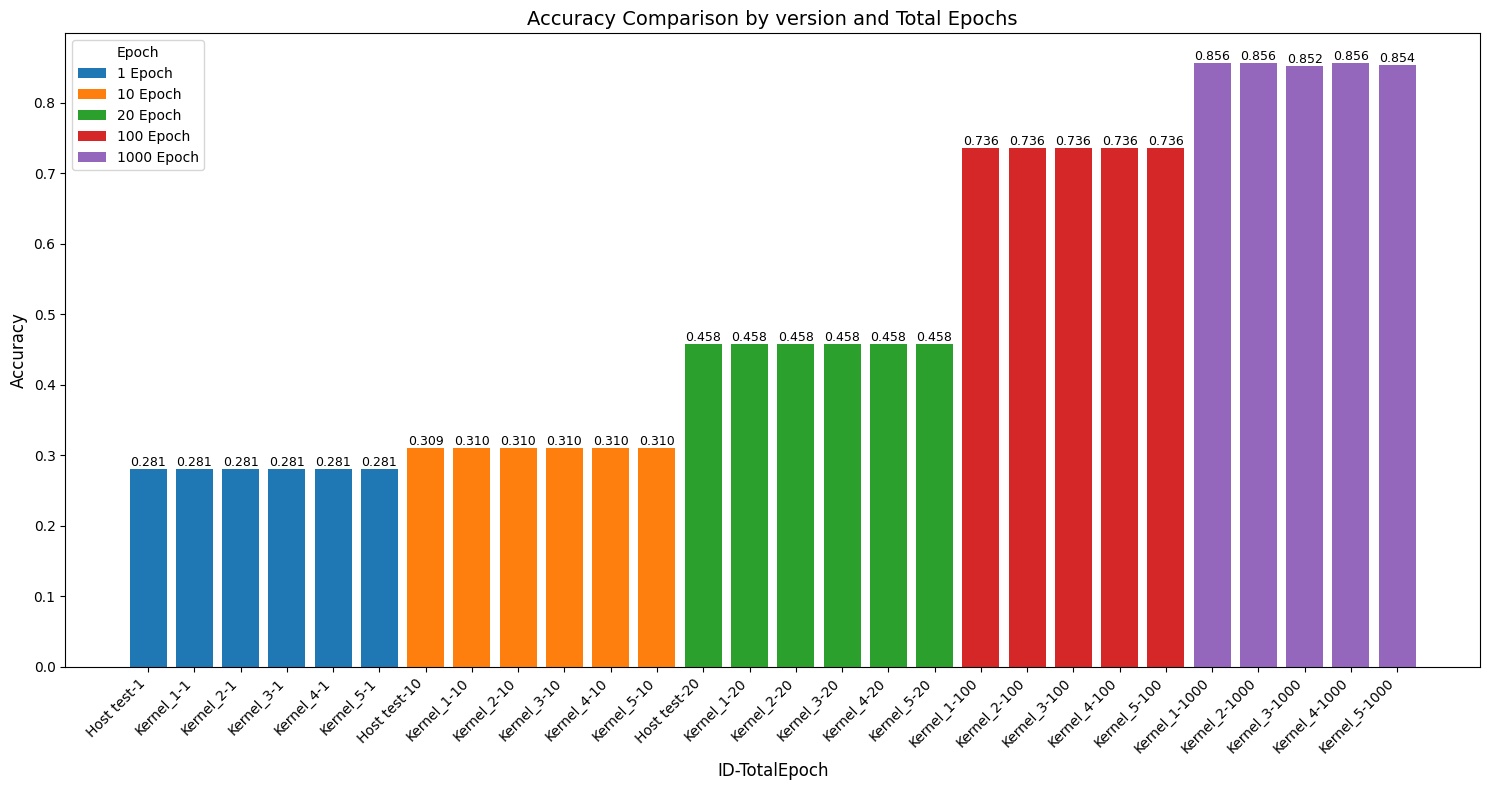

In [ ]:
accuracy_df['ID-TotalEpoch'] = accuracy_df['ID'] + '-' + accuracy_df['Total Epochs'].astype(str)

plt.figure(figsize=(15, 8))
for epoch in accuracy_df['Total Epochs'].unique():
    subset = accuracy_df[accuracy_df['Total Epochs'] == epoch]
    bars = plt.bar(subset['ID-TotalEpoch'], subset['Accuracy'], label=f'{epoch} Epoch')

    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width() / 2, height, f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.xlabel('ID-TotalEpoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Accuracy Comparison by version and Total Epochs', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.legend(title='Epoch', fontsize=10)
plt.tight_layout()
plt.show()

### Nhận xét:
- Thông qua 1, 10, 20 epochs: Độ chính xác của 5 phiên bản kernel bằng với độ chính xác của host.
 $→$ đảm bảo rằng các kernel đã được cài đặt đúng.
- Mở rộng cho 100 và 1000 epochs: Độ chính xác của 5 phiên bản kernel đạt được như nhau.


## 7.2 Độ lỗi và độ chính xác trong quá trình huấn luyện

Phần này nhóm chọn đánh giá trên 20 epochs, nhóm sẽ tiến hành so sánh độ lỗi của các phiên bản `qua từng epoch`.

In [ ]:
host_log_df = pd.read_csv("./log/host-training-log.csv")

# Vì trong quá trình log, chúng em vô tình truyền ngược thứ tự biến, nên các câu lệnh sau để cập nhật và xử lý số liệu lại cho phù hợp
# Đảm bảo không ảnh hưởng đến số liệu thời gian!
host_log_df.rename(columns={'Total Epochs': 'Temp', 'Epoch': 'Total Epochs'}, inplace=True)
host_log_df.rename(columns={'Temp': 'Epoch'}, inplace=True)

host_log_df['Total Epochs'] = host_log_df['Total Epochs'] - 1
host_log_df['Epoch'] = host_log_df['Epoch'] + 1
# Chỉ lấy lần huấn luyện có 20 epochs
host_log_df = host_log_df[host_log_df['Total Epochs'] == 20].reset_index(drop=True)

In [ ]:
# làm tương tự cho các file kernel log
kernel1_log_df = pd.read_csv("./log/kernel1-training-log.csv")
kernel1_log_20_df = kernel1_log_df[kernel1_log_df['Total Epochs'] == 20].reset_index(drop=True)

kernel2_log_df = pd.read_csv("./log/kernel2-training-log.csv")
kernel2_log_20_df = kernel2_log_df[kernel2_log_df['Total Epochs'] == 20].reset_index(drop=True)

kernel3_log_df = pd.read_csv("./log/kernel3-training-log.csv")
kernel3_log_20_df = kernel3_log_df[kernel3_log_df['Total Epochs'] == 20].reset_index(drop=True)

kernel4_log_df = pd.read_csv("./log/kernel4-training-log.csv")
kernel4_log_20_df = kernel4_log_df[kernel4_log_df['Total Epochs'] == 20].reset_index(drop=True)

kernel5_log_df = pd.read_csv("./log/kernel5-training-log.csv")
kernel5_log_20_df = kernel5_log_df[kernel4_log_df['Total Epochs'] == 20].reset_index(drop=True)


Tạo một Dataframe để so sánh và trực quan

In [ ]:
log20_df = pd.DataFrame(columns=['Total Epochs', 'Epoch'
                                  , 'Host Loss', 'Kernel1 Loss', 'Kernel2 Loss'
                                  , 'Kernel3 Loss', 'Kernel4 Loss','Kernel5 Loss','Host Accuracy'
                                  , 'Kernel1 Accuracy', 'Kernel2 Accuracy'
                                  , 'Kernel3 Accuracy', 'Kernel4 Accuracy', 'Kernel5 Accuracy'])

log20_df[['Total Epochs', 'Epoch', 'Host Loss', 'Host Accuracy']] = host_log_df[['Total Epochs', 'Epoch', 'Loss', 'Accuracy']].copy()
log20_df[['Kernel1 Loss', 'Kernel1 Accuracy']] = kernel1_log_20_df[['Loss', 'Accuracy']].copy()
log20_df[['Kernel2 Loss', 'Kernel2 Accuracy']] = kernel2_log_20_df[['Loss', 'Accuracy']].copy()
log20_df[['Kernel3 Loss', 'Kernel3 Accuracy']] = kernel3_log_20_df[['Loss', 'Accuracy']].copy()
log20_df[['Kernel4 Loss', 'Kernel4 Accuracy']] = kernel4_log_20_df[['Loss', 'Accuracy']].copy()
log20_df[['Kernel5 Loss', 'Kernel5 Accuracy']] = kernel4_log_20_df[['Loss', 'Accuracy']].copy()
log20_df=log20_df[log20_df['Total Epochs']>=log20_df['Epoch']]
log20_df

,Total Epochs,Epoch,Host Loss,Kernel1 Loss,Kernel2 Loss,Kernel3 Loss,Kernel4 Loss,Kernel5 Loss,Host Accuracy,Kernel1 Accuracy,Kernel2 Accuracy,Kernel3 Accuracy,Kernel4 Accuracy,Kernel5 Accuracy
0,20,1,2.303148,2.303148,2.303148,2.303148,2.303148,2.303148,0.087117,0.087117,0.087117,0.087117,0.087117,0.087117
1,20,2,2.253743,2.253743,2.253743,2.253743,2.253743,2.253743,0.281633,0.281633,0.281633,0.281633,0.281633,0.281633
2,20,3,2.121780,2.121780,2.121780,2.121780,2.121780,2.121780,0.246533,0.246567,0.246567,0.246567,0.246567,0.246567
3,20,4,2.002762,2.002778,2.002778,2.002777,2.002778,2.002778,0.216433,0.216383,0.216383,0.216383,0.216383,0.216383
4,20,5,2.048336,2.048337,2.048337,2.048337,2.048337,2.048337,0.235317,0.235317,0.235317,0.235317,0.235317,0.235317
5,20,6,1.842790,1.842801,1.842801,1.842800,1.842801,1.842801,0.395617,0.395617,0.395617,0.395617,0.395617,0.395617
6,20,7,1.772154,1.772151,1.772151,1.772151,1.772151,1.772151,0.404367,0.404383,0.404383,0.404383,0.404383,0.404383
7,20,8,1.699095,1.699104,1.699104,1.699104,1.699104,1.699104,0.239817,0.239817,0.239817,0.239817,0.239817,0.239817
8,20,9,1.643520,1.643519,1.643519,1.643520,1.643519,1.643519,0.473183,0.473217,0.473217,0.473217,0.473217,0.473217
9,20,10,1.566952,1.566966,1.566966,1.566967,1.566966,1.566966,0.354900,0.355000,0.355000,0.355000,0.355000,0.355000


Nhìn bằng mắt thường, ta nhận thấy độ chính xác và độ lỗi qua từng epoch hầu như không khác biệt. Nhóm tiến hành trực quan để xem thử.

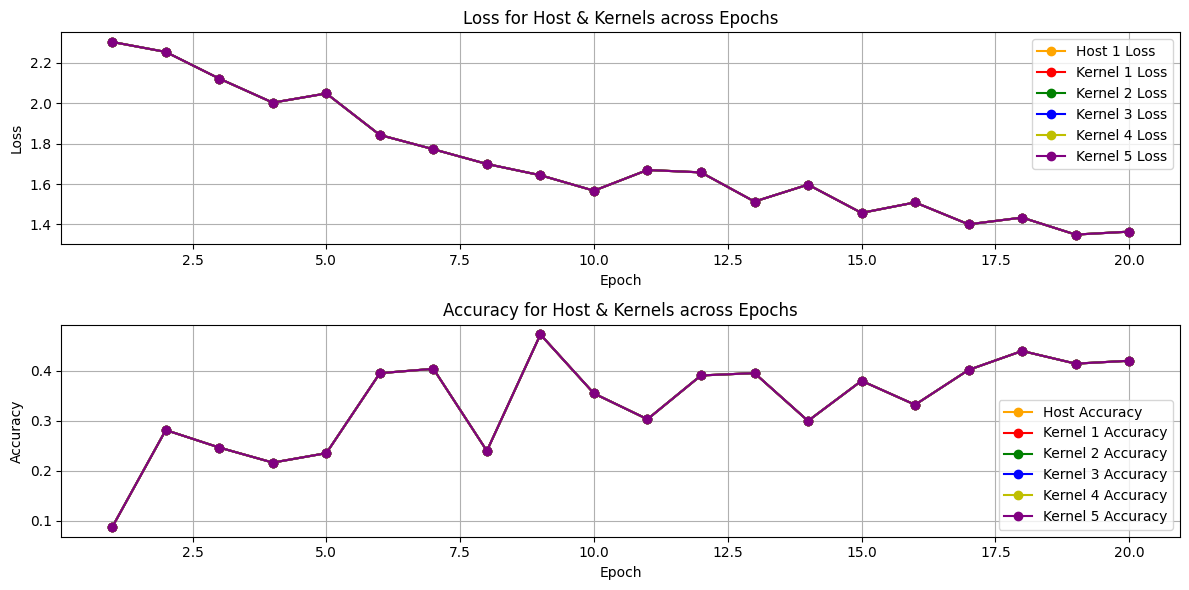

In [ ]:
df = log20_df
# Vẽ biểu đồ cho Loss
plt.figure(figsize=(12, 6))

# Vẽ các đường loss cho các kernel
plt.subplot(2, 1, 1)
plt.plot(df['Epoch'], df['Host Loss'], label='Host 1 Loss', color='orange', marker='o')
plt.plot(df['Epoch'], df['Kernel1 Loss'], label='Kernel 1 Loss', color='r', marker='o')
plt.plot(df['Epoch'], df['Kernel2 Loss'], label='Kernel 2 Loss', color='g', marker='o')
plt.plot(df['Epoch'], df['Kernel3 Loss'], label='Kernel 3 Loss', color='b', marker='o')
plt.plot(df['Epoch'], df['Kernel4 Loss'], label='Kernel 4 Loss', color='y', marker='o')
plt.plot(df['Epoch'], df['Kernel5 Loss'], label='Kernel 5 Loss', color='purple', marker='o')
plt.title('Loss for Host & Kernels across Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)

# Vẽ biểu đồ Accuracy
plt.subplot(2, 1, 2)
plt.plot(df['Epoch'], df['Host Accuracy'], label='Host Accuracy', color='orange', marker='o')
plt.plot(df['Epoch'], df['Kernel1 Accuracy'], label='Kernel 1 Accuracy', color='r', marker='o')
plt.plot(df['Epoch'], df['Kernel2 Accuracy'], label='Kernel 2 Accuracy', color='g', marker='o')
plt.plot(df['Epoch'], df['Kernel3 Accuracy'], label='Kernel 3 Accuracy', color='b', marker='o')
plt.plot(df['Epoch'], df['Kernel4 Accuracy'], label='Kernel 4 Accuracy', color='y', marker='o')
plt.plot(df['Epoch'], df['Kernel5 Accuracy'], label='Kernel 5 Accuracy', color='purple', marker='o')
plt.title('Accuracy for Host & Kernels across Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)

plt.tight_layout()
plt.show()

### Nhận xét:
- Đồ thị của cả 6 phiên bản trùng nhau hoàn toàn
$→$ Cho thấy về `độ chính xác` các phiên bản đảm bảo như nhau.

## 7.3 Xem xét khả năng huấn luyện của mô hình

Vì độ chính xác và độ lỗi của mô hình là như nhau cho các phiên bản, vậy nên nhóm chúng em chỉ lấy phiên bản kernel1 với 1000 epochs làm đại diện cho toàn bộ các phiên bản.

(để trực quan dễ nhìn, chúng em xin phép làm mịn biểu đồ với window_size =5)

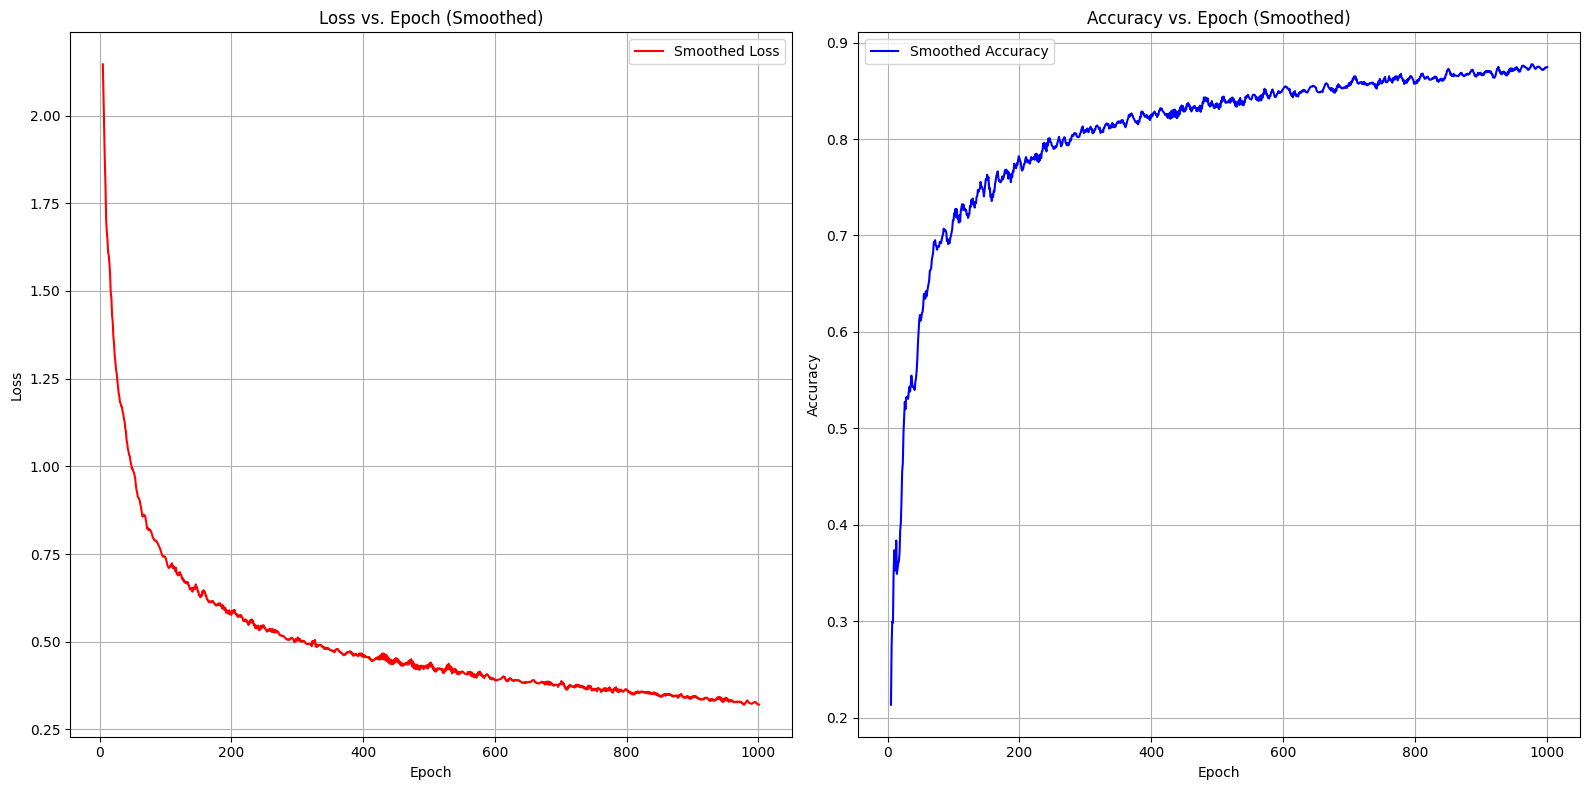

In [ ]:
kernel1_log_df = pd.read_csv("./log/kernel1-training-log.csv")
kernel1_log_df = kernel1_log_df.iloc[277:]

# Hàm tính moving average để làm mịn biểu đồ
def moving_average(data, window_size):
    return np.convolve(data, np.ones(window_size) / window_size, mode='valid')

# Làm mịn
window_size = 5
smoothed_loss = moving_average(kernel1_log_df['Loss'], window_size)
smoothed_accuracy = moving_average(kernel1_log_df['Accuracy'], window_size)
smoothed_epoch = kernel1_log_df['Epoch'][window_size - 1:]

fig, axs = plt.subplots(1, 2, figsize=(16, 8), sharex=True)
axs[0].plot(smoothed_epoch, smoothed_loss, label='Smoothed Loss', color='red')
axs[0].set_title('Loss vs. Epoch (Smoothed)')
axs[0].set_ylabel('Loss')
axs[0].set_xlabel('Epoch')
axs[0].legend()
axs[0].grid(True)

axs[1].plot(smoothed_epoch, smoothed_accuracy, label='Smoothed Accuracy', color='blue')
axs[1].set_title('Accuracy vs. Epoch (Smoothed)')
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Accuracy')
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()


## 7.4 So sánh kết quả cải thiện của các phiên bản

In [ ]:
time_df = pd.read_csv('./log/time-log.csv')

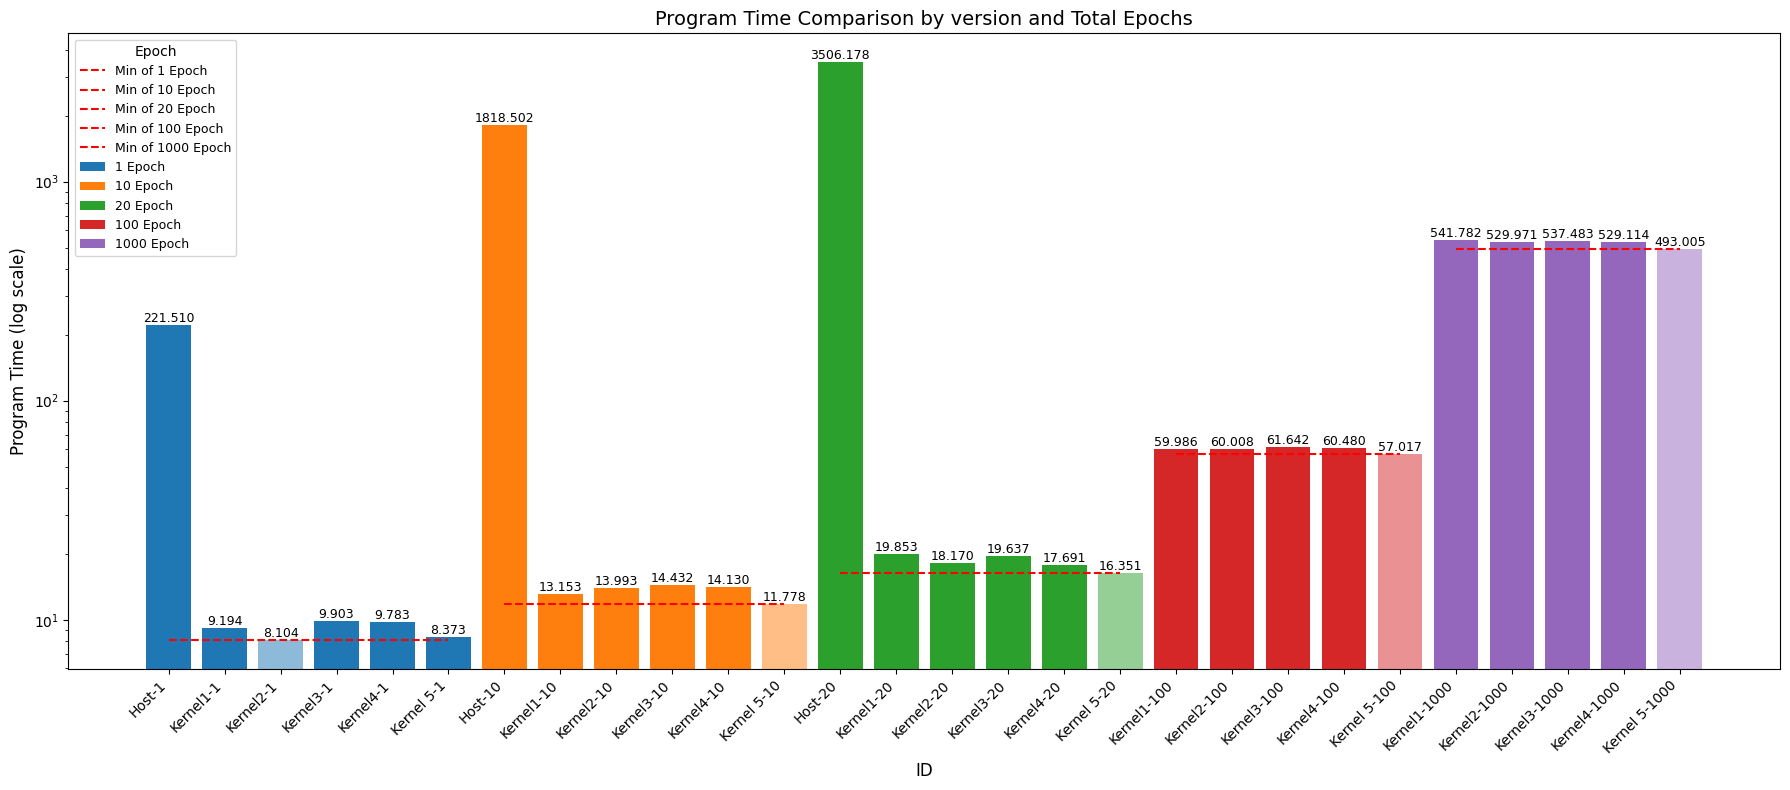

In [ ]:
time_df['ID-TotalEpoch'] = time_df['ID'] + '-' + time_df['Total Epochs'].astype(str)

# Tạo một danh sách các màu sắc cho từng nhóm epoch (mục đích là để làm nổi bật kernel có kết quả tốt nhất)
epoch_colors = plt.cm.tab10(range(len(time_df['Total Epochs'].unique())))

plt.figure(figsize=(18, 8))
for i, epoch in enumerate(time_df['Total Epochs'].unique()):
    subset = time_df[time_df['Total Epochs'] == epoch]

    # Tìm giá trị nhỏ nhất và ID tương ứng
    min_value = subset['Program Time'].min()
    min_id = subset[subset['Program Time'] == min_value]['ID-TotalEpoch'].iloc[0]

    colors = []
    for x in subset['ID-TotalEpoch']:
        if x == min_id:
            rgba = list(epoch_colors[i])
            rgba[-1] = 0.5
            colors.append(tuple(rgba))
        else:
            colors.append(epoch_colors[i])

    bars = plt.bar(
        subset['ID-TotalEpoch'],
        subset['Program Time'],
        color=colors,
        label=f'{epoch} Epoch'
    )

    plt.hlines(y=min_value, xmin=subset['ID-TotalEpoch'].iloc[0], xmax=subset['ID-TotalEpoch'].iloc[-1],
               colors='red', linestyles='dashed', label=f'Min of {epoch} Epoch')

    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2, height,
            f'{height:.3f}', ha='center', va='bottom', fontsize=9
        )

plt.yscale('log')  # ở đây vì kết quả của CPU là rất rất lớn so với GPU, nên em chọn scale theo log để có kết quả trực quan tốt hơn
plt.xlabel('ID', fontsize=12)
plt.ylabel('Program Time (log scale)', fontsize=12)
plt.title('Program Time Comparison by version and Total Epochs', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.legend(title='Epoch', fontsize=9)
plt.tight_layout()
plt.show()


### Nhận xét:
- Với 1 epoch: Kernel2 cho hiệu suất đáng kinh ngạc khi so với các phiên bản khác.
- Với 20 Epochs: Kernel2 và Kernel4 thể hiện được ưu thế của mình.
- Với 100 và 1000 epochs: Các phiên bản cải tiến đều thể hiện được ưu thế của mình khi giảm được từ 5-10s so với kernel gốc.
- Đặc biệt là kernel 5 (phiên bản kết hợp giữa kernel3 và kernel4) đã thể hiện được ưu thế vượt trội của mình trong hầu hết các trường hợp.

Tiếp đến, để so sánh kỹ hơn về phần mà nhóm đang tập trung tối ưu: ` hàm nhân ma trận `, nhóm tiến hành chỉ so sánh thời gian nhân ma trận của các phiên bản.

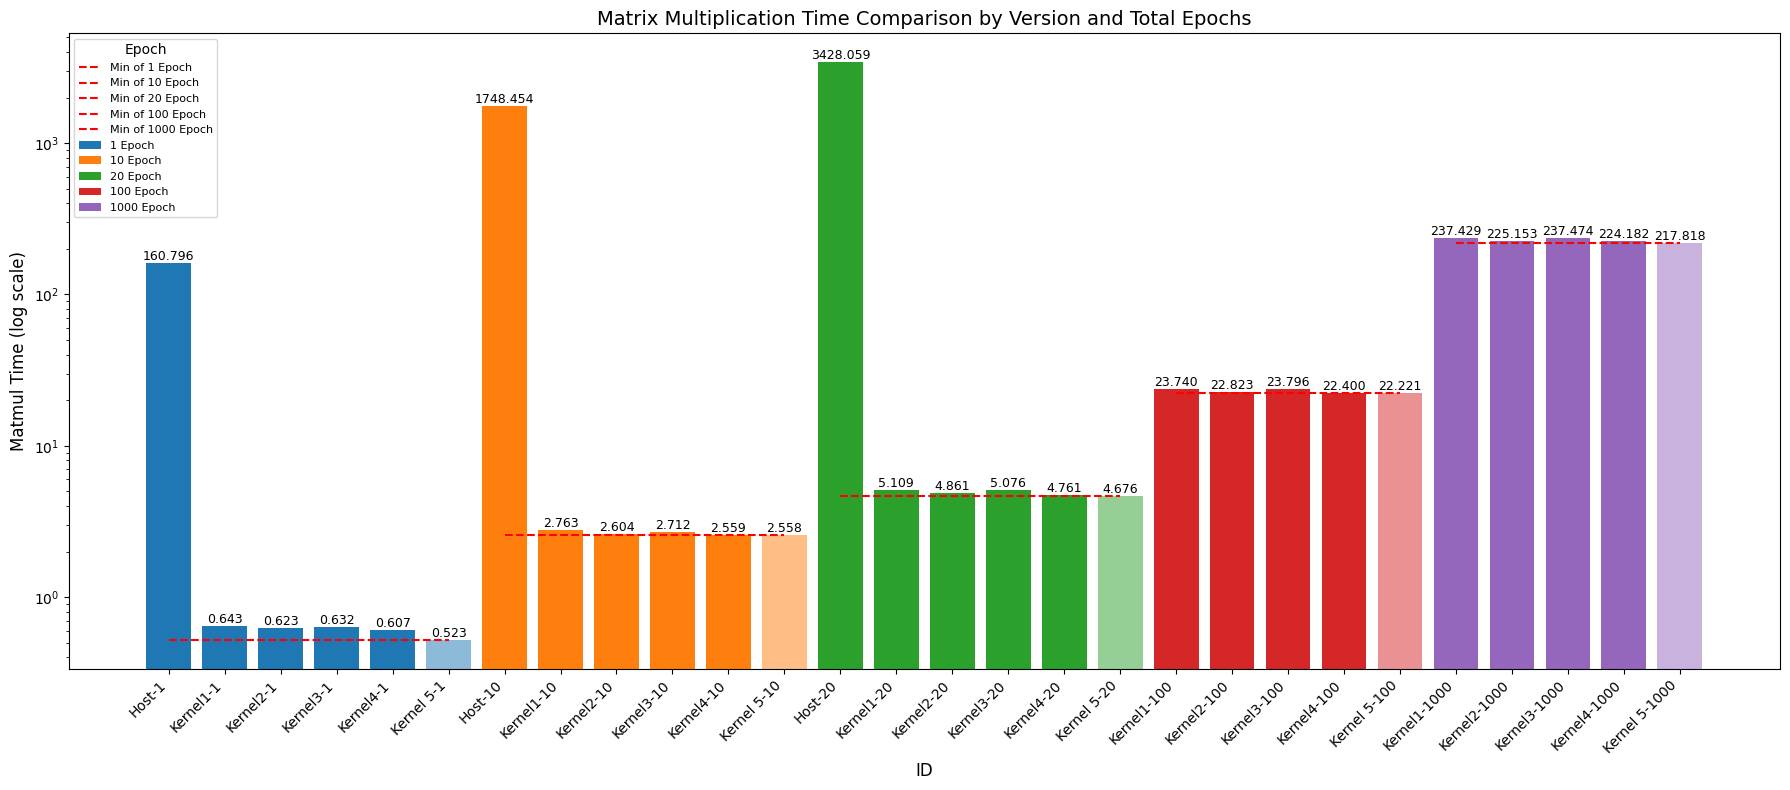

In [ ]:
plt.figure(figsize=(18, 8))
for i, epoch in enumerate(time_df['Total Epochs'].unique()):
    subset = time_df[time_df['Total Epochs'] == epoch]

    min_value = subset['Matmul Time'].min()
    min_id = subset[subset['Matmul Time'] == min_value]['ID-TotalEpoch'].iloc[0]

    colors = []
    for x in subset['ID-TotalEpoch']:
        if x == min_id:
            rgba = list(epoch_colors[i])
            rgba[-1] = 0.5
            colors.append(tuple(rgba))
        else:
            colors.append(epoch_colors[i])

    bars = plt.bar(
        subset['ID-TotalEpoch'],
        subset['Matmul Time'],
        color=colors,
        label=f'{epoch} Epoch'
    )

    plt.hlines(y=min_value, xmin=subset['ID-TotalEpoch'].iloc[0], xmax=subset['ID-TotalEpoch'].iloc[-1],
               colors='red', linestyles='dashed', label=f'Min of {epoch} Epoch')

    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2, height,
            f'{height:.3f}', ha='center', va='bottom', fontsize=9
        )

plt.yscale('log')
plt.xlabel('ID', fontsize=12)
plt.ylabel('Matmul Time (log scale)', fontsize=12)
plt.title('Matrix Multiplication Time Comparison by Version and Total Epochs', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.legend(title='Epoch', fontsize=8, loc='upper left')
plt.tight_layout()

plt.show()


1. Tất cả các kernel đều cải thiện được RẤT NHIỀU khi so với Host
1. Các phiên bản cải tiến đều giảm được thời gian khi so với kernel1 - kernel cơ bản
1. Kernel2 và Kernel4 có sử dụng SMEM nên cùng đạt hiệu suất tốt hơn.
1. Kernel5 cho ra hiệu suất tốt nhất trong cả 5 phiên bản (qua tất cả epoch size).

In [ ]:
gpu_df = pd.read_csv("./GPU_track.csv")
gpu_df['Time(%)'] = gpu_df['Time(%)']*100
gpu_df

,ID,Name,n_epochs,Time(%),Time (ms),Calls,Avg (ms),Min (us),Max (ms)
0,Kernel1,Basic,1,15.73,161.55,14,11.5390,168.830,42.343
1,Kernel2,SMEM,1,13.86,132.72,14,9.4803,140.190,33.227
2,Kernel3,AtomicAdd,1,16.64,162.74,14,11.6240,171.450,44.044
3,Kernel4,Unrolling,1,13.65,128.80,14,9.2000,88.062,34.841
4,Kernel1,Basic,100,10.93,5028.82,866,5.8070,3.360,45.407
5,Kernel2,SMEM,100,8.82,3948.61,866,4.5596,9.216,33.232
6,Kernel3,AtomicAdd,100,10.98,5036.28,866,5.8156,3.456,42.948
7,Kernel4,Unrolling,100,8.26,3677.33,866,4.2463,5.311,32.226
8,Kernel1,Basic,1000,10.79,49113.10,8066,6.0889,3.455,42.351
9,Kernel2,SMEM,1000,8.68,38612.20,8066,4.7870,9.216,34.021


## 7.5 So sánh % thời gian sử dụng GPU cho kernel Nhân ma trận của các phiên bản

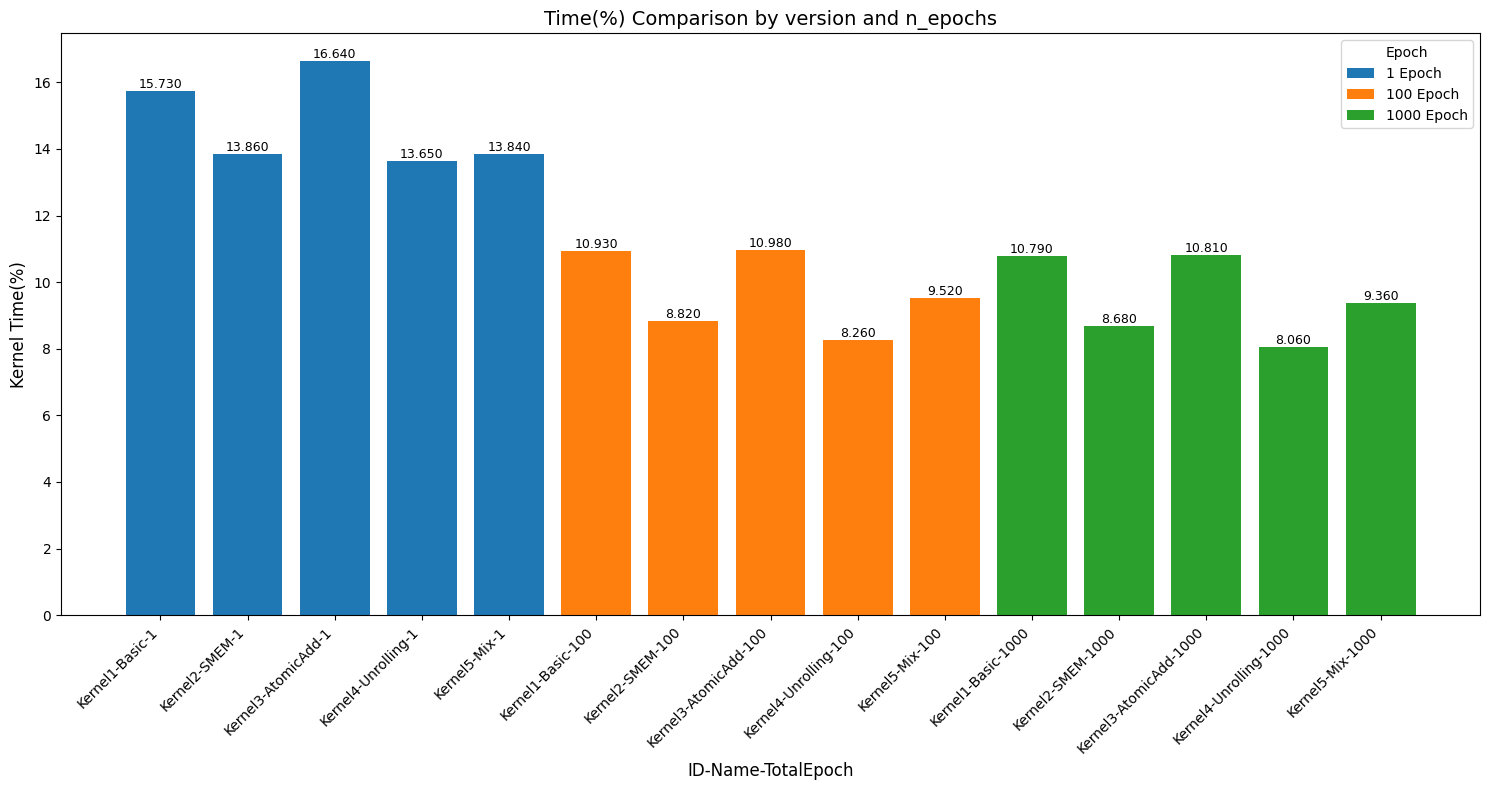

In [ ]:
# Tạo cột kết hợp cho trục x
gpu_df['ID-Name-TotalEpoch'] = gpu_df['ID'] + '-' + gpu_df['Name'].astype(str) + '-' + gpu_df['n_epochs'].astype(str)

# Sắp xếp DataFrame theo 'n_epochs' và 'ID'
gpu_df = gpu_df.sort_values(by=['n_epochs', 'ID'])

# Vẽ biểu đồ
plt.figure(figsize=(15, 8))
for epoch in gpu_df['n_epochs'].unique():
    subset = gpu_df[gpu_df['n_epochs'] == epoch]
    bars = plt.bar(subset['ID-Name-TotalEpoch'], subset['Time(%)'], label=f'{epoch} Epoch')

    # Thêm giá trị trên đầu mỗi cột
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2, height,
            f'{height:.3f}', ha='center', va='bottom', fontsize=9
        )

# Tùy chỉnh biểu đồ
plt.xlabel('ID-Name-TotalEpoch', fontsize=12)
plt.ylabel('Kernel Time(%)', fontsize=12)
plt.title('Time(%) Comparison by version and n_epochs', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.legend(title='Epoch', fontsize=10)
plt.tight_layout()

# Hiển thị biểu đồ
plt.show()

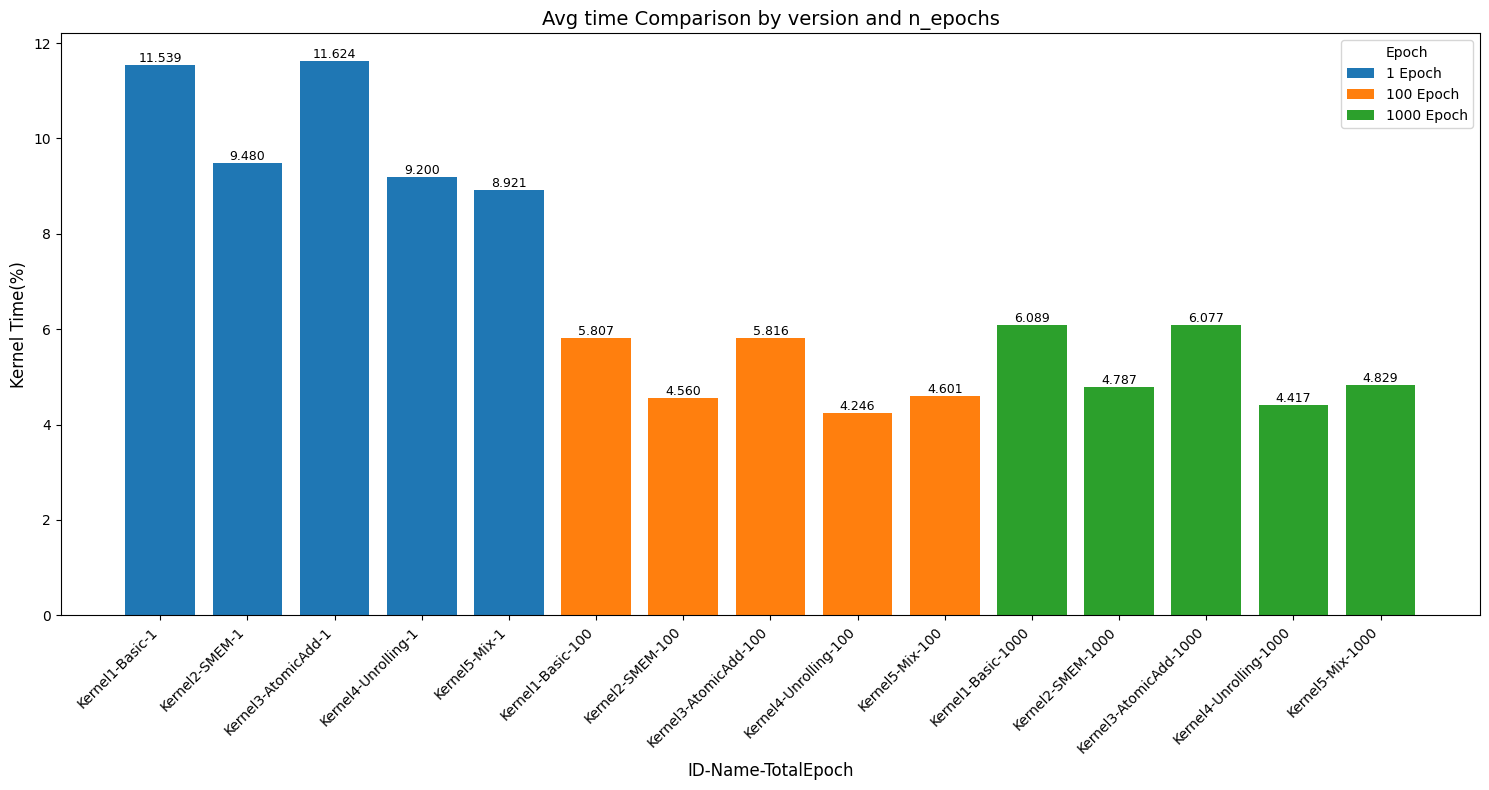

In [ ]:
# Tạo cột kết hợp cho trục x
gpu_df['ID-Name-TotalEpoch'] = gpu_df['ID'] + '-' + gpu_df['Name'].astype(str) + '-' + gpu_df['n_epochs'].astype(str)

# Sắp xếp DataFrame theo 'n_epochs' và 'ID'
gpu_df = gpu_df.sort_values(by=['n_epochs', 'ID'])

# Vẽ biểu đồ
plt.figure(figsize=(15, 8))
for epoch in gpu_df['n_epochs'].unique():
    subset = gpu_df[gpu_df['n_epochs'] == epoch]
    bars = plt.bar(subset['ID-Name-TotalEpoch'], subset['Avg (ms)'], label=f'{epoch} Epoch')

    # Thêm giá trị trên đầu mỗi cột
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2, height,
            f'{height:.3f}', ha='center', va='bottom', fontsize=9
        )

# Tùy chỉnh biểu đồ
plt.xlabel('ID-Name-TotalEpoch', fontsize=12)
plt.ylabel('Kernel Time(%)', fontsize=12)
plt.title('Avg time Comparison by version and n_epochs', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.legend(title='Epoch', fontsize=10)
plt.tight_layout()

# Hiển thị biểu đồ
plt.show()